In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Configuración para visualización
plt.style.use('ggplot')
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Configurar directorios
results_dir = '../results'
plots_dir = '../results/plots/final_results'

# Crear directorio de plots si no existe
os.makedirs(plots_dir, exist_ok=True)

# Contador para numeración automática de plots
plot_counter = 1

In [2]:
def save_plot(filename=None, dpi=300, bbox_inches='tight'):
    """
    Guarda el plot actual en el directorio de plots.
    Si no se especifica nombre, usa numeración automática.
    """
    global plot_counter
    
    if filename is None:
        filename = f"plot_{plot_counter:02d}_resultado.png"
        plot_counter += 1
    
    # Asegurar que termine en .png
    if not filename.endswith('.png'):
        filename += '.png'
    
    filepath = os.path.join(plots_dir, filename)
    plt.savefig(filepath, dpi=dpi, bbox_inches=bbox_inches)
    print(f"Gráfico guardado: {os.path.basename(filepath)}")

def show_and_save(filename=None):
    """
    Muestra el plot y lo guarda automáticamente.
    """
    save_plot(filename)
    plt.show()
    plt.close()

def format_model_name(pkl_name):
    """
    Convierte el nombre del archivo PKL al nombre legible del modelo.
    """

    model_mapping = {
        'random_forest': 'Random Forest',
        'k_nearest_neighbors': 'K-Nearest Neighbors',
        'svm_polinomico': 'SVM Polinómico',
        'svm_sigmoide': 'SVM Sigmoide',
        'svm_rbf': 'SVM RBF'
    }
    
    # Limpiar el nombre del archivo
    base_name = pkl_name.replace('_predictions.pkl', '').replace('.pkl', '')
    
    # Devolver el nombre formateado o el original si no está en el mapeo
    return model_mapping.get(base_name, base_name.replace('_', ' ').title())

In [3]:
# Lista de métodos de sampling disponibles
sampling_methods = ['original', 'smote', 'adasyn', 'smote_tomek']

# Diccionario para almacenar las tablas
results_tables = {}
missing_files = []

# Cargar cada archivo CSV
for method in sampling_methods:
    csv_path = os.path.join(results_dir, f"results_{method}.csv")
    
    if os.path.exists(csv_path):
        # Cargar el CSV
        df = pd.read_csv(csv_path)
        results_tables[method] = df
        print(f"{method.upper():<12} - {df.shape[0]} modelos, {df.shape[1]} columnas")
        
        # Mostrar las columnas del primer archivo para referencia
        if method == sampling_methods[0]:
            print(f"\n  Columnas: {', '.join(df.columns.tolist())}")
            print()
    else:
        missing_files.append(method)
        print(f"{method.upper():<12} - Archivo no encontrado")

# Crear tabla unificada
unified_data = []

# Combinar todos los dataframes
for method, df in results_tables.items():
    # Para cada fila del dataframe
    for idx, row in df.iterrows():
        # Crear diccionario con toda la información
        row_data = {
            'Método': method.replace('_', ' ').title(),
            **row.to_dict()   # Todas las columnas del CSV
        }
        unified_data.append(row_data)

# Crear DataFrame unificado
unified_df = pd.DataFrame(unified_data)

# Mostrar información sobre la tabla unificada
print(f"\nTabla unificada creada exitosamente")
print(f"   Total de filas: {len(unified_df)}")
print(f"   Total de columnas: {len(unified_df.columns)}")
print(f"   Métodos incluidos: {', '.join(unified_df['Método'].unique())}")
print(f"   Modelos incluidos: {', '.join(unified_df['Modelo'].unique())}")

# Guardar tabla unificada
output_path = os.path.join(results_dir, 'resultados_unificados.csv')
unified_df.to_csv(output_path, index=False)
print(f"\nTabla unificada guardada en: resultados_unificados.csv")

display(unified_df)

ORIGINAL     - 5 modelos, 10 columnas

  Columnas: Modelo, Accuracy, Precision, Recall, F1-Score, ROC-AUC, PR-AUC, False Positive Rate, Train Time (s), Prediction Time (s)

SMOTE        - 5 modelos, 10 columnas
ADASYN       - 5 modelos, 10 columnas
SMOTE_TOMEK  - 5 modelos, 10 columnas

Tabla unificada creada exitosamente
   Total de filas: 20
   Total de columnas: 11
   Métodos incluidos: Original, Smote, Adasyn, Smote Tomek
   Modelos incluidos: Random Forest, K-Nearest Neighbors, SVM Polinómico, SVM Sigmoide, SVM RBF

Tabla unificada guardada en: resultados_unificados.csv


,Método,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,False Positive Rate,Train Time (s),Prediction Time (s)
0,Original,Random Forest,0.999561,0.929412,0.806122,0.863388,0.952769,0.872467,0.000106,58.130314,0.249988
1,Original,K-Nearest Neighbors,0.999508,0.960526,0.744898,0.839080,0.918246,0.860121,0.000053,0.041461,53.247644
2,Original,SVM Polinómico,0.999122,0.760870,0.714286,0.736842,0.947699,0.797347,0.000387,255.456358,0.581871
3,Original,SVM Sigmoide,0.998560,0.617647,0.428571,0.506024,0.731252,0.347016,0.000457,57.153295,1.219020
4,Original,SVM RBF,0.999280,0.782178,0.806122,0.793970,0.945351,0.787897,0.000387,111.329176,3.214249
5,Smote,Random Forest,0.999491,0.870968,0.826531,0.848168,0.973011,0.866403,0.000211,139.449402,0.312952
6,Smote,K-Nearest Neighbors,0.997507,0.393204,0.826531,0.532895,0.922792,0.705311,0.002198,0.065372,66.092740
7,Smote,SVM Polinómico,0.983866,0.087437,0.887755,0.159195,0.973981,0.678941,0.015968,14614.899276,157.553278
8,Smote,SVM Sigmoide,0.736684,0.004983,0.765306,0.009902,0.819929,0.163776,0.263365,19347.597631,389.548635
9,Smote,SVM RBF,0.984621,0.091387,0.887755,0.165714,0.966054,0.713080,0.015212,7507.445279,228.150879


In [6]:
# Diccionario para almacenar las predicciones
predictions_data = {}

# Para cada método de sampling
for method in sampling_methods:
    method_predictions = {}
    method_dir = os.path.join(results_dir, 'models', method)
    
    if os.path.exists(method_dir):
        print(f"\n{method.upper()}:")
        
        # Buscar archivos de predicciones
        pkl_files = [f for f in os.listdir(method_dir) if f.endswith('_predictions.pkl')]
        
        if not pkl_files:
            print("  No se encontraron archivos de predicciones")
            continue
        
        # Cargar cada archivo PKL
        for file in pkl_files:
            model_name = format_model_name(file)
            pred_path = os.path.join(method_dir, file)
            
            try:
                with open(pred_path, 'rb') as f:
                    pred_data = pickle.load(f)
                    method_predictions[model_name] = pred_data
                    
                    # Obtener información detallada
                    y_test = pred_data.get('y_test', [])
                    y_test_len = len(y_test)
                    
                    # Contar fraudes y no fraudes reales
                    if len(y_test) > 0:
                        fraudes_reales = sum(y_test)
                        no_fraudes_reales = y_test_len - fraudes_reales
                        porcentaje_fraudes = (fraudes_reales / y_test_len) * 100
                        
                        print(f"  {model_name:<25} - {y_test_len:,} muestras totales")
                        print(f"    No fraudes: {no_fraudes_reales:,} ({100-porcentaje_fraudes:.2f}%)")
                        print(f"    Fraudes: {fraudes_reales:,} ({porcentaje_fraudes:.2f}%)")
                    
            except Exception as e:
                print(f"  Error con {file}: {str(e)}")
        
        predictions_data[method] = method_predictions
        print(f"  Total modelos cargados: {len(method_predictions)}")
     
    else:
        print(f"\n{method.upper()}: Directorio no encontrado")

# Resumen final
total_models = sum(len(models) for models in predictions_data.values())
print(f"\nTotal métodos con predicciones: {len(predictions_data)}")
print(f"Total modelos con predicciones: {total_models}")


ORIGINAL:
  K-Nearest Neighbors       - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  Random Forest             - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  Svm Polinómico            - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  SVM RBF                   - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  SVM Sigmoide              - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  Total modelos cargados: 5

SMOTE:
  K-Nearest Neighbors       - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  Random Forest             - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  Svm Polinómico            - 56,962 muestras totales
    No fraudes: 56,864 (99.83%)
    Fraudes: 98 (0.17%)
  SVM RBF                   - 56,962 muestras totales
    No fraudes: 56,

Gráfico guardado: 01_metricas_principales_comparacion.png


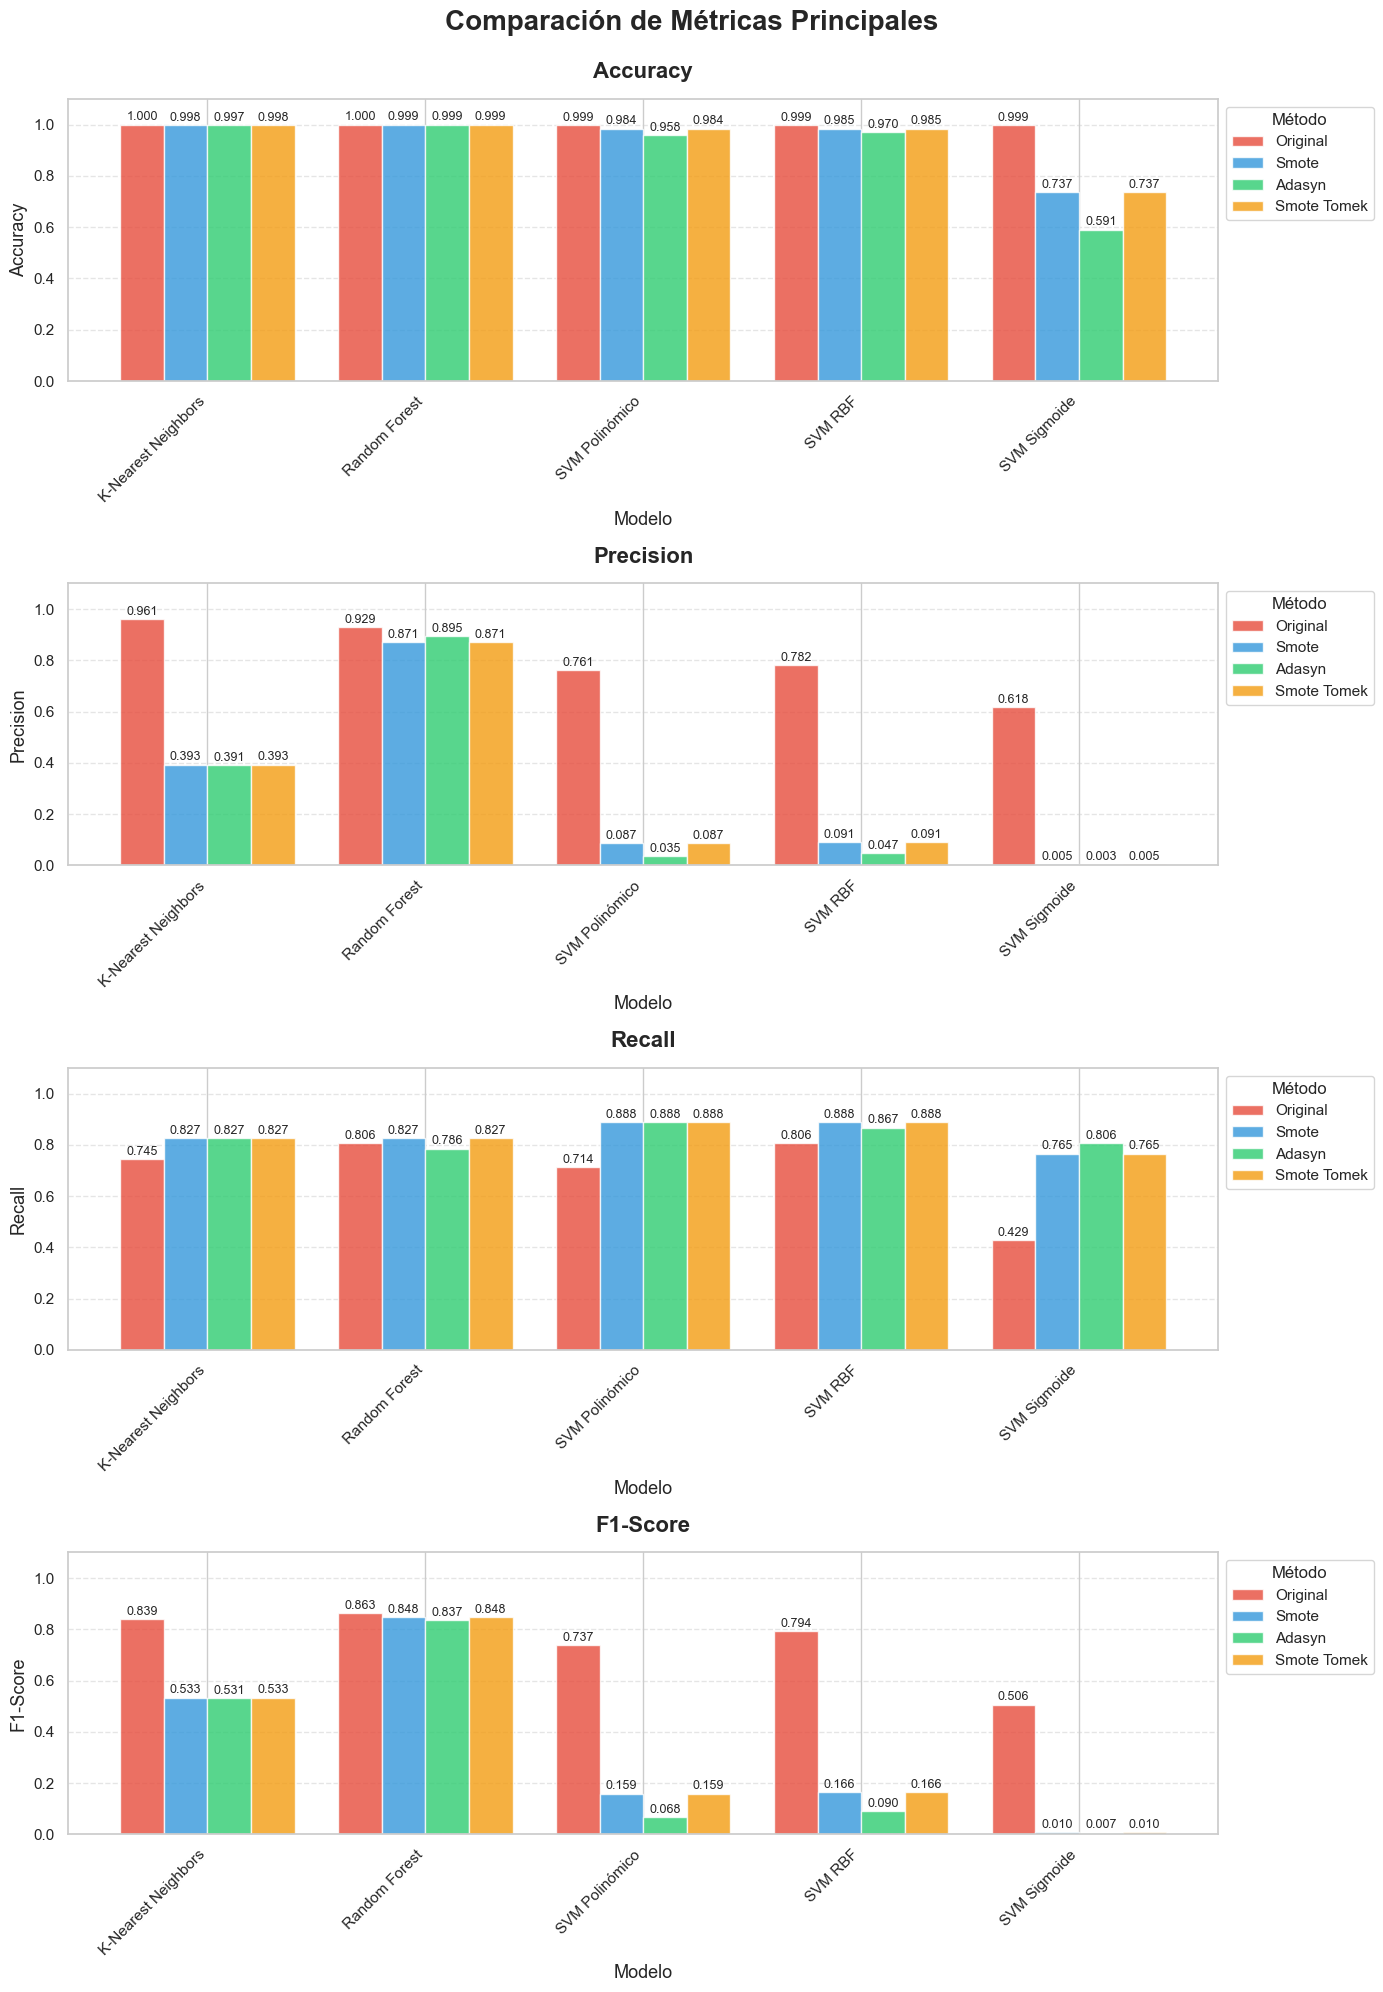

In [13]:
# Definir colores para cada método de sampling
method_colors = {
    'Original': '#e74c3c',      # Rojo
    'Smote': '#3498db',         # Azul
    'Adasyn': '#2ecc71',        # Verde
    'Smote Tomek': '#f39c12'    # Naranja
}

# Métricas principales a visualizar
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

# Crear figura con subplots
fig, axes = plt.subplots(4, 1, figsize=(14, 20))

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    
    # Preparar datos para el gráfico
    pivot_data = unified_df.pivot_table(
        values=metric, 
        index='Modelo', 
        columns='Método'
    )
    
    # Configurar posiciones de las barras
    x = np.arange(len(pivot_data.index))
    width = 0.2  
    multiplier = 0
    
    # Crear barras para cada método
    for attribute, color in method_colors.items():
        if attribute in pivot_data.columns:
            offset = width * multiplier
            bars = ax.bar(x + offset, pivot_data[attribute], width, 
                          label=attribute, color=color, alpha=0.8)
            
            # Añadir valores sobre las barras
            for bar in bars:
                height = bar.get_height()
                if not np.isnan(height):
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                           f'{height:.3f}', ha='center', va='bottom', fontsize=9)
            
            multiplier += 1
    
    # Configuración del subplot
    ax.set_title(f'{metric}', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Modelo', fontsize=13)
    ax.set_ylabel(metric, fontsize=13)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=11)
    ax.legend(title='Método', bbox_to_anchor=(1, 1), loc='upper left', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0, 1.1)

plt.suptitle('Comparación de Métricas Principales', fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
show_and_save('01_metricas_principales_comparacion')


Generando matrices de confusión para ORIGINAL...

K-Nearest Neighbors:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,861         3
Real Fraude      25        73

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,861
  • Falsos Positivos (FP): 3
  • Falsos Negativos (FN): 25
  • Verdaderos Positivos (TP): 73
  • Tasa de FP: 0.01%
  • Tasa de FN: 25.51%

Random Forest:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,858         6
Real Fraude      19        79

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,858
  • Falsos Positivos (FP): 6
  • Falsos Negativos (FN): 19
  • Verdaderos Positivos (TP): 79
  • Tasa de FP: 0.01%
  • Tasa de FN: 19.39%

Svm Polinómico:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,842        22
Real Fraude      28        70

Métricas derivadas:
  • Verdaderos Neg

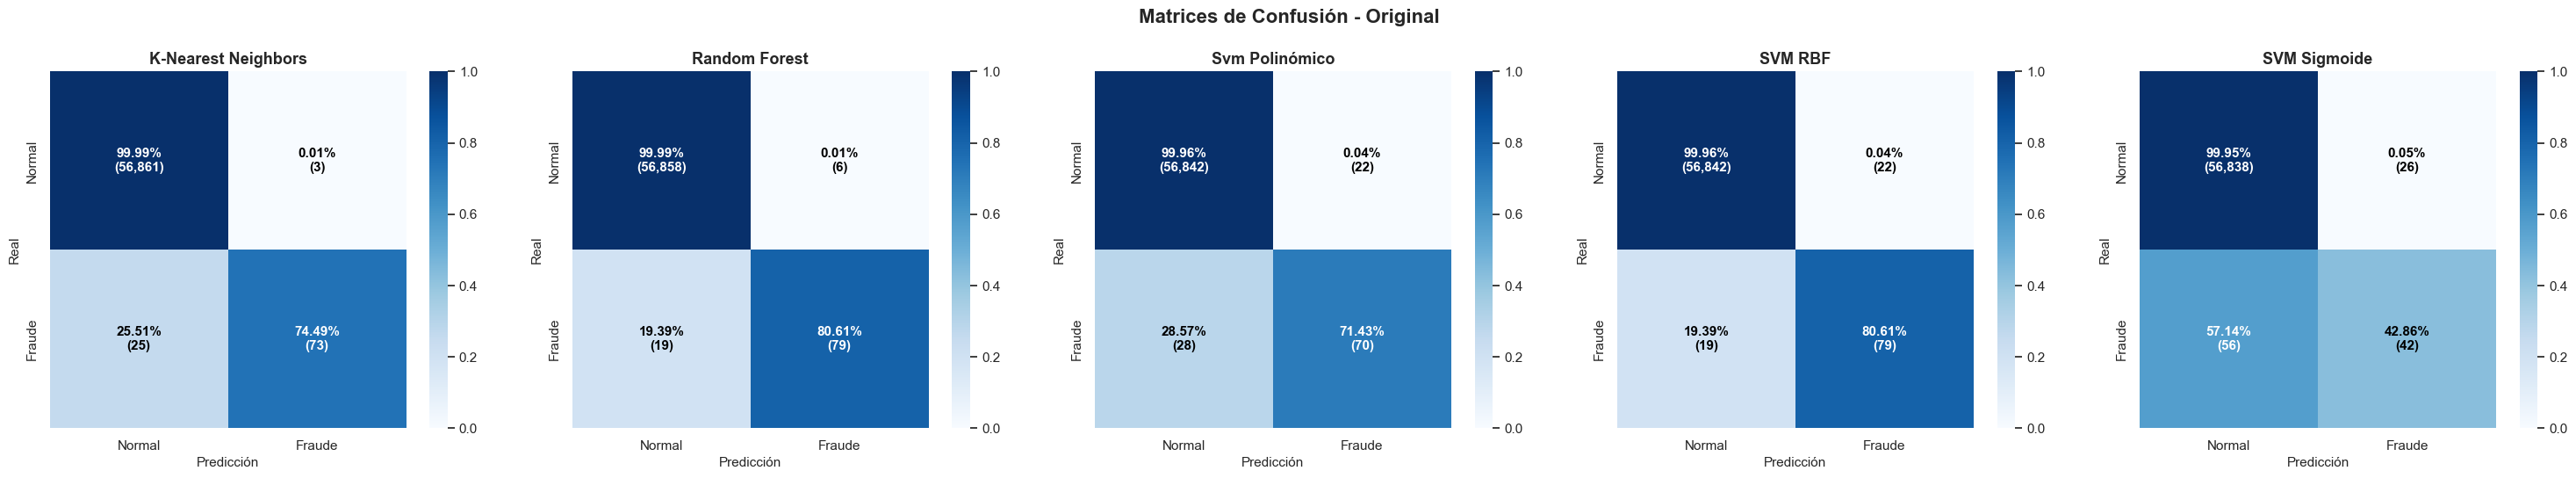


Generando matrices de confusión para SMOTE...

K-Nearest Neighbors:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,739       125
Real Fraude      17        81

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,739
  • Falsos Positivos (FP): 125
  • Falsos Negativos (FN): 17
  • Verdaderos Positivos (TP): 81
  • Tasa de FP: 0.22%
  • Tasa de FN: 17.35%

Random Forest:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,852        12
Real Fraude      17        81

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,852
  • Falsos Positivos (FP): 12
  • Falsos Negativos (FN): 17
  • Verdaderos Positivos (TP): 81
  • Tasa de FP: 0.02%
  • Tasa de FN: 17.35%

Svm Polinómico:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  55,956       908
Real Fraude      11        87

Métricas derivadas:
  • Verdaderos Neg

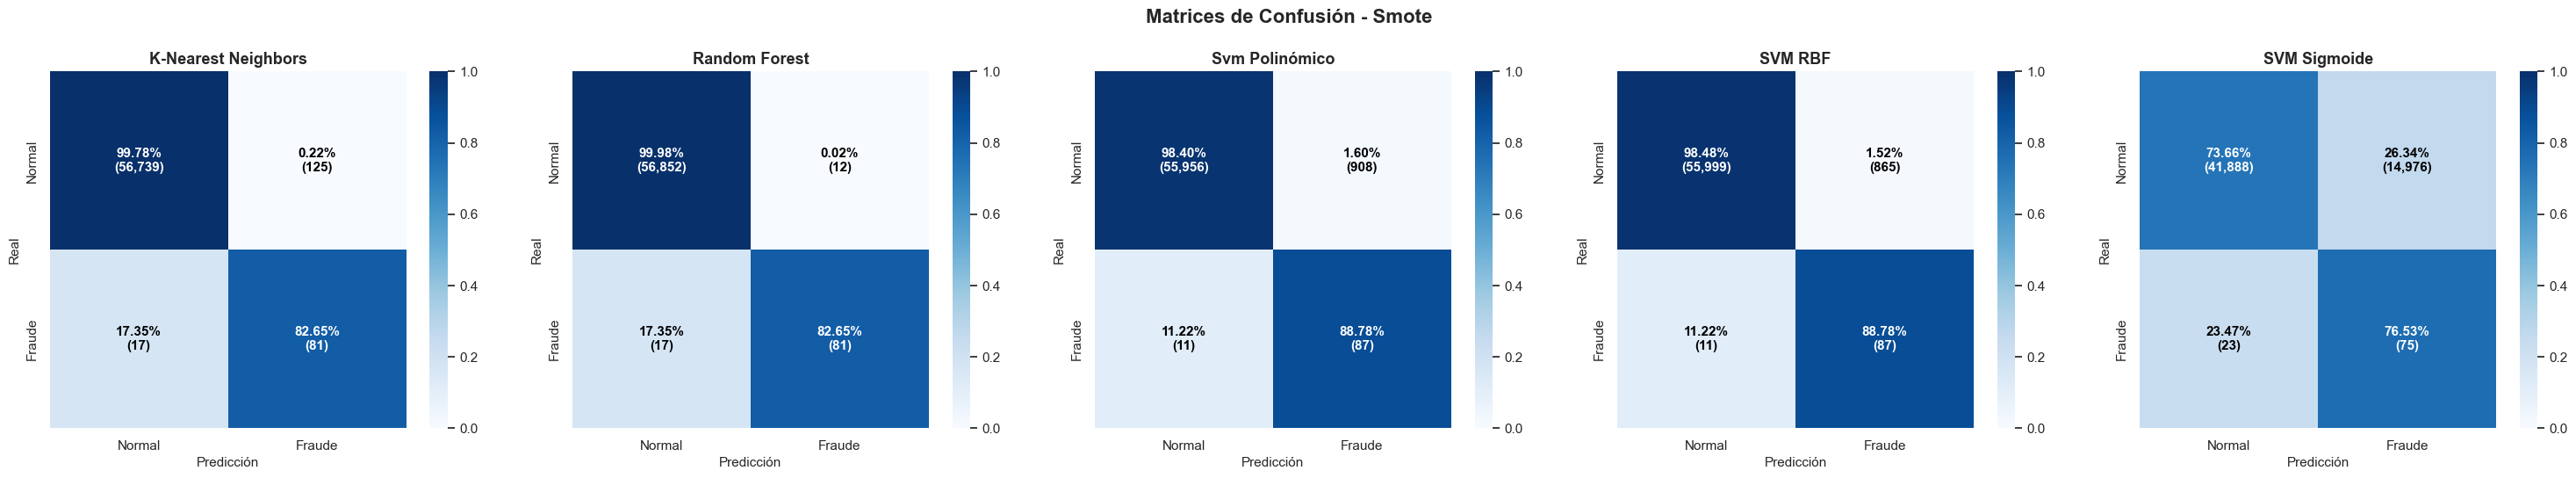


Generando matrices de confusión para ADASYN...

K-Nearest Neighbors:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,738       126
Real Fraude      17        81

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,738
  • Falsos Positivos (FP): 126
  • Falsos Negativos (FN): 17
  • Verdaderos Positivos (TP): 81
  • Tasa de FP: 0.22%
  • Tasa de FN: 17.35%

Random Forest:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,855         9
Real Fraude      21        77

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,855
  • Falsos Positivos (FP): 9
  • Falsos Negativos (FN): 21
  • Verdaderos Positivos (TP): 77
  • Tasa de FP: 0.02%
  • Tasa de FN: 21.43%

Svm Polinómico:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  54,489     2,375
Real Fraude      11        87

Métricas derivadas:
  • Verdaderos Neg

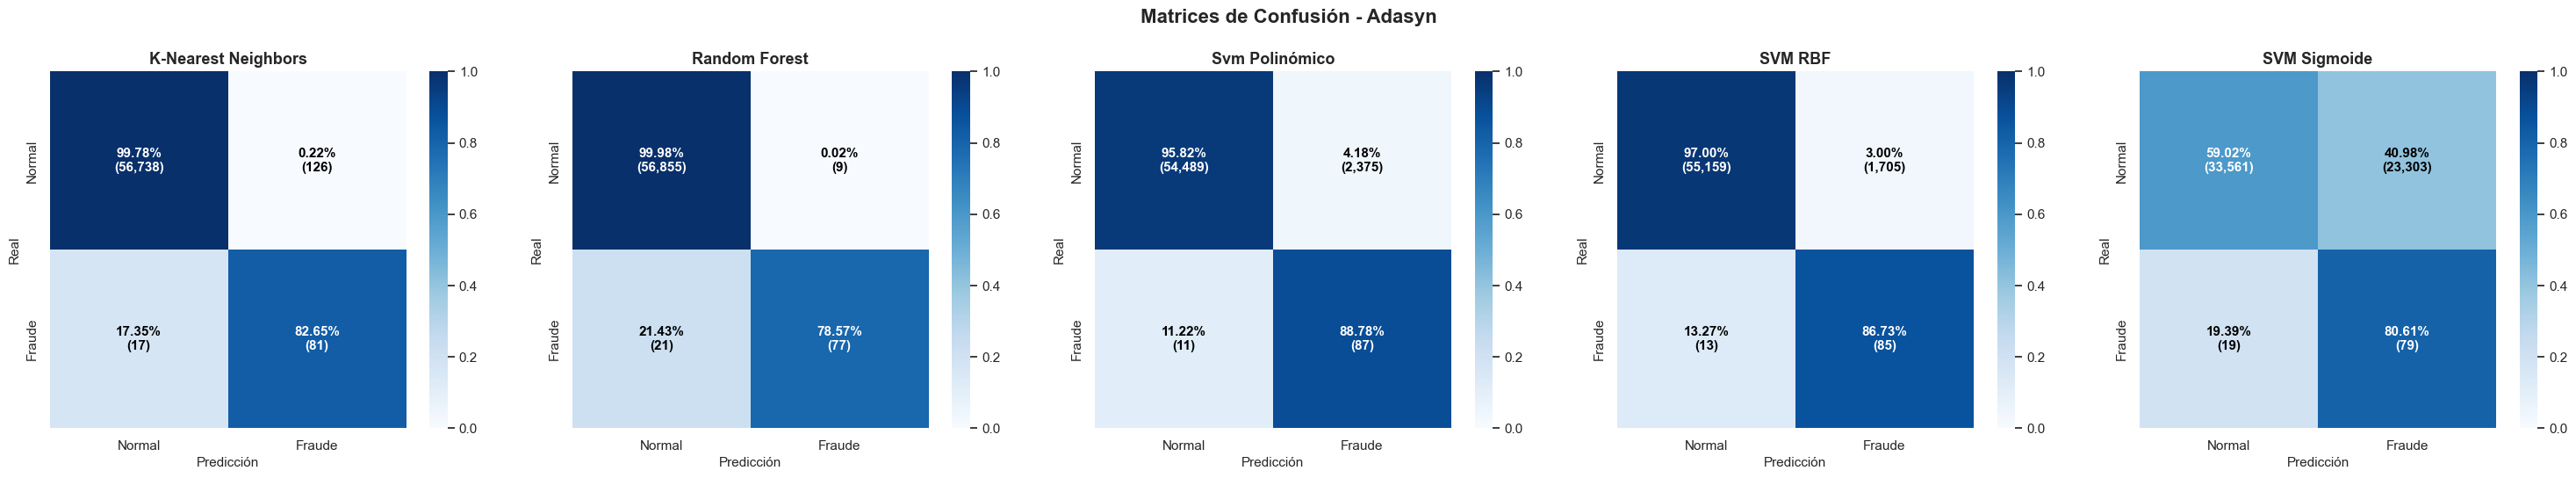


Generando matrices de confusión para SMOTE_TOMEK...

K-Nearest Neighbors:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,739       125
Real Fraude      17        81

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,739
  • Falsos Positivos (FP): 125
  • Falsos Negativos (FN): 17
  • Verdaderos Positivos (TP): 81
  • Tasa de FP: 0.22%
  • Tasa de FN: 17.35%

Random Forest:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  56,852        12
Real Fraude      17        81

Métricas derivadas:
  • Verdaderos Negativos (TN): 56,852
  • Falsos Positivos (FP): 12
  • Falsos Negativos (FN): 17
  • Verdaderos Positivos (TP): 81
  • Tasa de FP: 0.02%
  • Tasa de FN: 17.35%

Svm Polinómico:
----------------------------------------
              Predicción
           Normal    Fraude
Real Normal  55,956       908
Real Fraude      11        87

Métricas derivadas:
  • Verdader

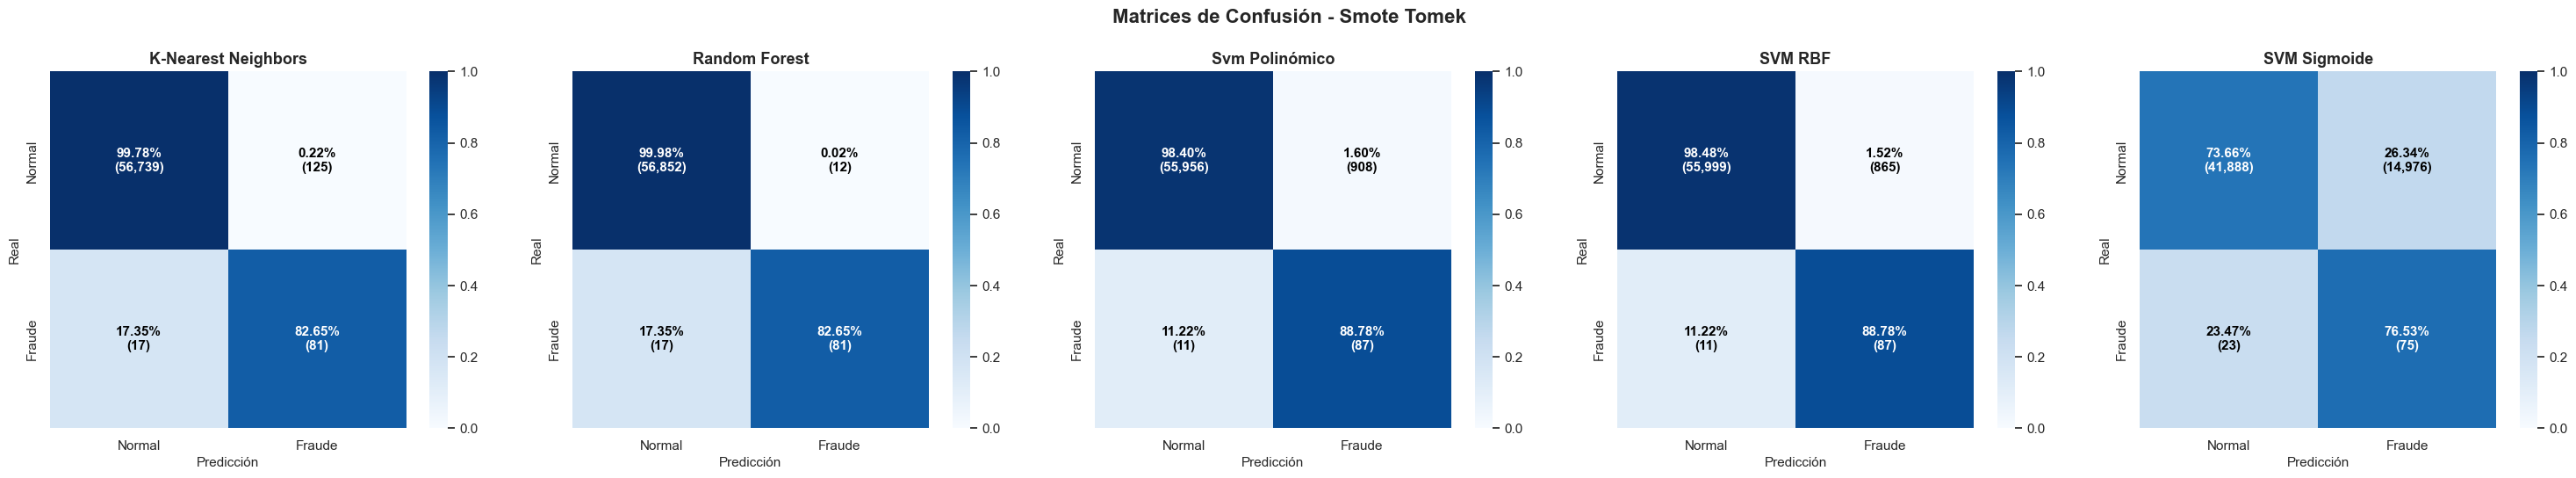

In [124]:
# Visualizar matrices de confusión para cada método
for method, models_pred in predictions_data.items():
    if not models_pred:
        continue
    
    # Contar modelos disponibles
    n_models = len(models_pred)
    
    # Configurar la figura - todos los modelos en una fila
    plt.figure(figsize=(6*n_models, 5))
    
    print(f"\nGenerando matrices de confusión para {method.upper()}")
    print("="*60)
    
    # Para cada modelo en este método
    for i, (model_name, pred_data) in enumerate(models_pred.items()):
        plt.subplot(1, n_models, i+1)
        
        # Obtener o calcular matriz de confusión
        if 'confusion_matrix' in pred_data:
            cm = pred_data['confusion_matrix']
        else:
            # Si no está guardada, calcularla
            y_test = pred_data['y_test']
            y_pred = pred_data['y_pred']
            cm = confusion_matrix(y_test, y_pred)
        
        # Imprimir matriz de confusión
        print(f"\n{model_name}:")
        print("-" * 40)
        print("              Predicción")
        print("           Normal    Fraude")
        print(f"Real Normal  {cm[0,0]:6,d}    {cm[0,1]:6,d}")
        print(f"Real Fraude  {cm[1,0]:6,d}    {cm[1,1]:6,d}")
        
        # Calcular métricas adicionales
        tn, fp, fn, tp = cm.ravel()
        print(f"\nMétricas derivadas:")
        print(f"  • Verdaderos Negativos (TN): {tn:,d}")
        print(f"  • Falsos Positivos (FP): {fp:,d}")
        print(f"  • Falsos Negativos (FN): {fn:,d}")
        print(f"  • Verdaderos Positivos (TP): {tp:,d}")
        print(f"  • Tasa de FP: {fp/(fp+tn)*100:.2f}%")
        print(f"  • Tasa de FN: {fn/(fn+tp)*100:.2f}%")
        
        # Normalizar para mostrar porcentajes
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Crear heatmap
        sns.heatmap(cm_norm, annot=False, fmt='.2%', cmap='Blues', 
                    xticklabels=['Normal', 'Fraude'],
                    yticklabels=['Normal', 'Fraude'],
                    cbar=True, square=True, vmin=0, vmax=1)
        
        # Añadir anotaciones personalizadas con porcentajes y conteos
        for row in range(cm.shape[0]):
            for col in range(cm.shape[1]):
                percentage = cm_norm[row, col] * 100
                count = cm[row, col]
                # Color del texto según el valor
                color = 'white' if cm_norm[row, col] > 0.5 else 'black'
                plt.text(col+0.5, row+0.5, f'{percentage:.2f}%\n({count:,})', 
                        ha='center', va='center', fontsize=11, 
                        color=color, fontweight='bold')
        
        plt.title(f'{model_name}', fontsize=13, fontweight='bold')
        plt.xlabel('Predicción', fontsize=11)
        plt.ylabel('Real', fontsize=11)
    
    # Resumen del método
    print(f"\n{'='*60}")
    print(f"RESUMEN {method.upper()}:")
    total_tp = sum(confusion_matrix(pred_data['y_test'], pred_data['y_pred'])[1,1] 
                   for pred_data in models_pred.values())
    total_fn = sum(confusion_matrix(pred_data['y_test'], pred_data['y_pred'])[1,0] 
                   for pred_data in models_pred.values())
    print(f"Total fraudes detectados por todos los modelos: {total_tp:,d}")
    print(f"Total fraudes no detectados por todos los modelos: {total_fn:,d}")
    
    # Título general para el método
    plt.suptitle(f'Matrices de Confusión - {method.replace("_", " ").title()}', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    show_and_save(f'02_matrices_confusion_{method}')


Generando curvas ROC para ORIGINAL
Gráfico guardado: 03_curvas_roc_original.png


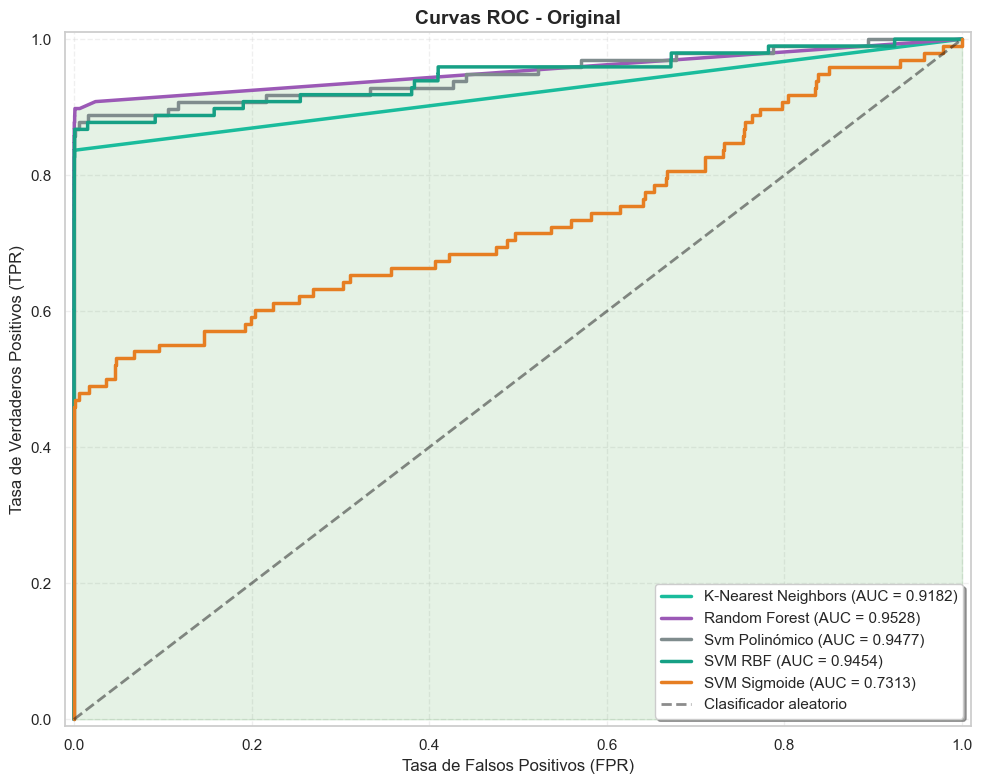


Generando curvas ROC para SMOTE
Gráfico guardado: 03_curvas_roc_smote.png


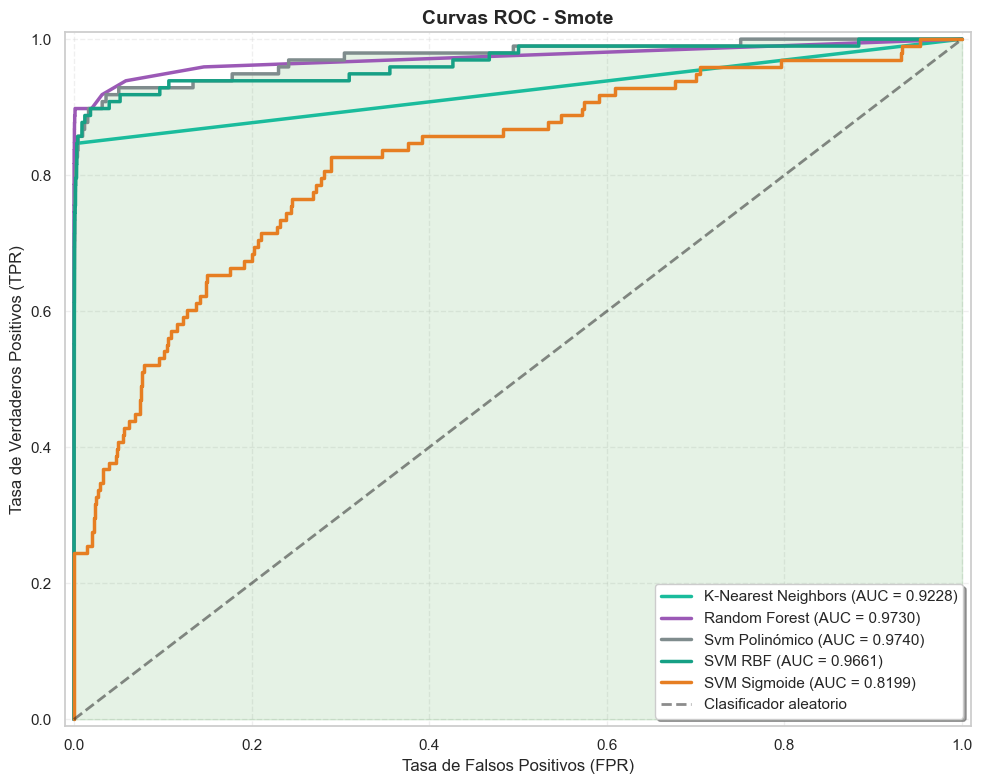


Generando curvas ROC para ADASYN
Gráfico guardado: 03_curvas_roc_adasyn.png


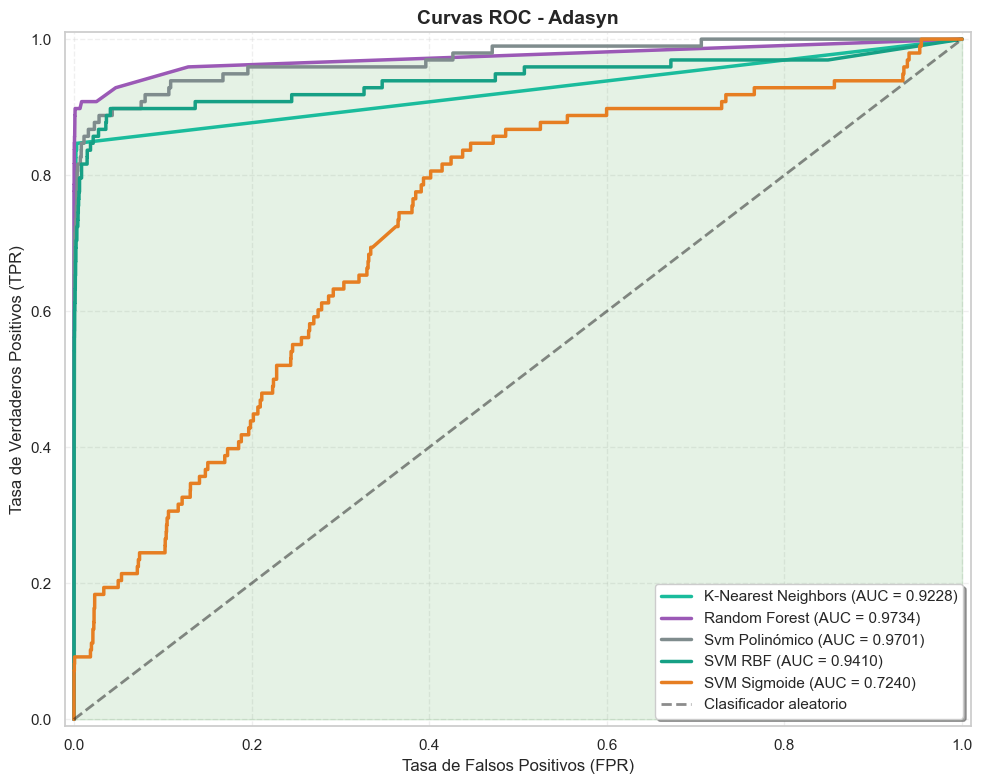


Generando curvas ROC para SMOTE_TOMEK
Gráfico guardado: 03_curvas_roc_smote_tomek.png


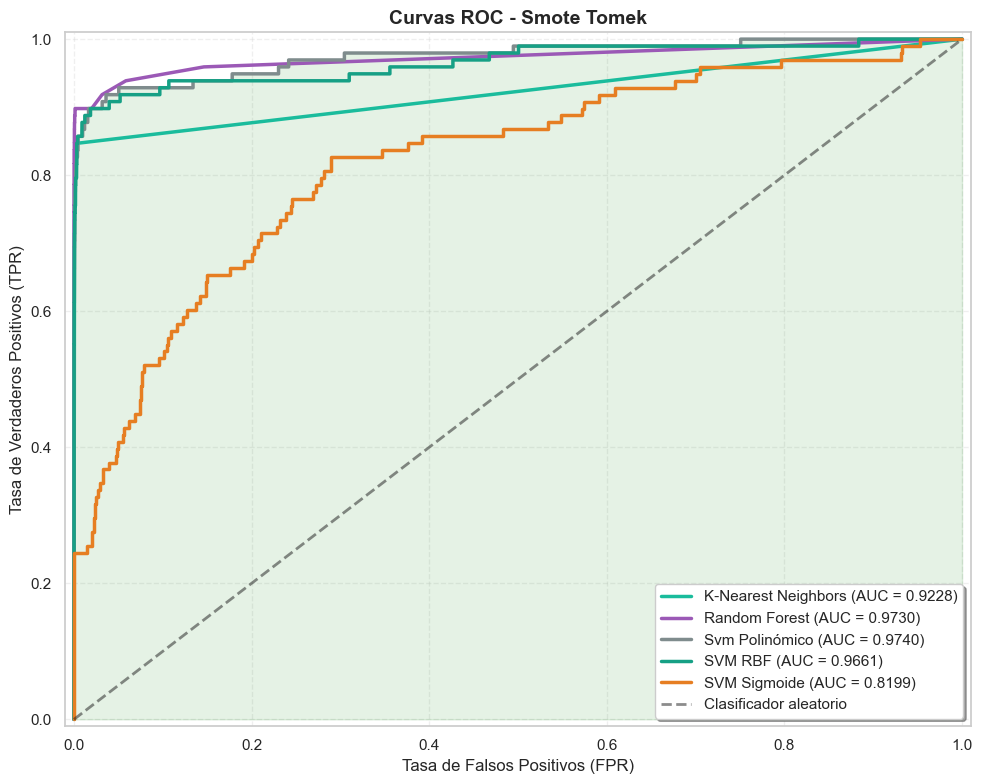

In [128]:
# Colores para cada modelo
model_colors = {
    'Random Forest': '#9b59b6',        
    'K-Nearest Neighbors': '#1abc9c',  
    'SVM Polinómico': '#34495e',       
    'SVM Sigmoide': '#e67e22',         
    'SVM RBF': '#16a085'               
}

# Generar curvas ROC para cada método
for method, models_pred in predictions_data.items():
    if not models_pred:
        continue
    
    plt.figure(figsize=(10, 8))
    
    print(f"\nGenerando curvas ROC para {method.upper()}")
    
    # Para cada modelo en este método
    for model_name, pred_data in models_pred.items():
        if pred_data.get('y_prob') is not None:
            # Obtener datos
            y_true = pred_data['y_test']
            y_prob = pred_data['y_prob']
            
            # Calcular curva ROC
            fpr, tpr, _ = roc_curve(y_true, y_prob)
            roc_auc = auc(fpr, tpr)
            
            # Obtener color del modelo
            color = model_colors.get(model_name, '#7f8c8d')
            
            # Dibujar curva
            plt.plot(fpr, tpr, lw=2.5, color=color, 
                    label=f'{model_name} (AUC = {roc_auc:.4f})')
    
    # Línea diagonal de referencia
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Clasificador aleatorio')
    
    # Configuración del gráfico
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
    plt.title(f'Curvas ROC - {method.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", frameon=True, fancybox=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    # Añadir área sombreada bajo la mejor curva
    best_auc = 0
    best_fpr = None
    best_tpr = None
    
    for model_name, pred_data in models_pred.items():
        if pred_data.get('y_prob') is not None:
            fpr, tpr, _ = roc_curve(pred_data['y_test'], pred_data['y_prob'])
            current_auc = auc(fpr, tpr)
            if current_auc > best_auc:
                best_auc = current_auc
                best_fpr = fpr
                best_tpr = tpr
    
    # Sombrear área bajo la mejor curva
    if best_fpr is not None:
        plt.fill_between(best_fpr, 0, best_tpr, alpha=0.1, color='green')
    
    plt.tight_layout()
    show_and_save(f'03_curvas_roc_{method}')


Generando curvas Precision-Recall para ORIGINAL
Gráfico guardado: 04_curvas_precision_recall_original.png


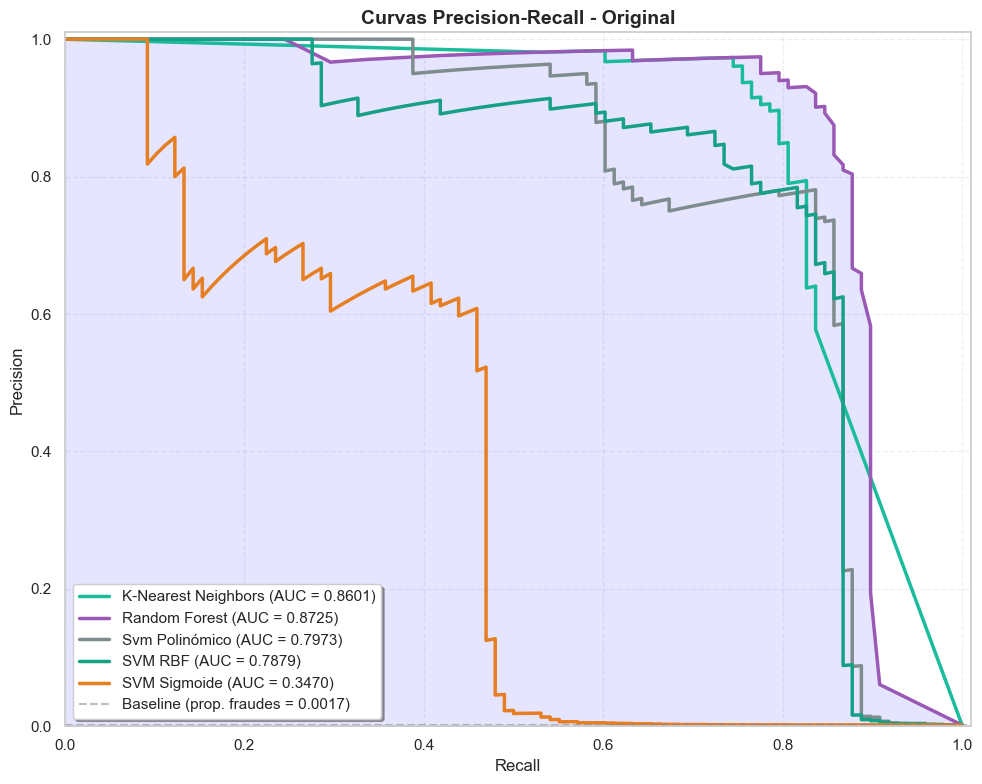


Generando curvas Precision-Recall para SMOTE
Gráfico guardado: 04_curvas_precision_recall_smote.png


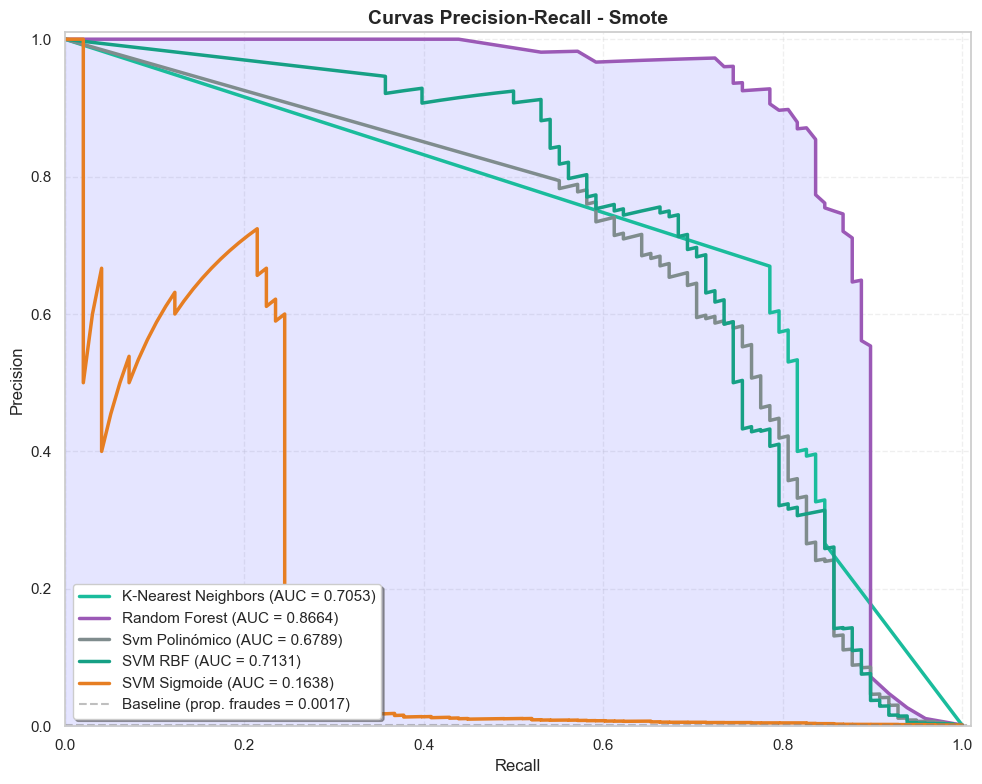


Generando curvas Precision-Recall para ADASYN
Gráfico guardado: 04_curvas_precision_recall_adasyn.png


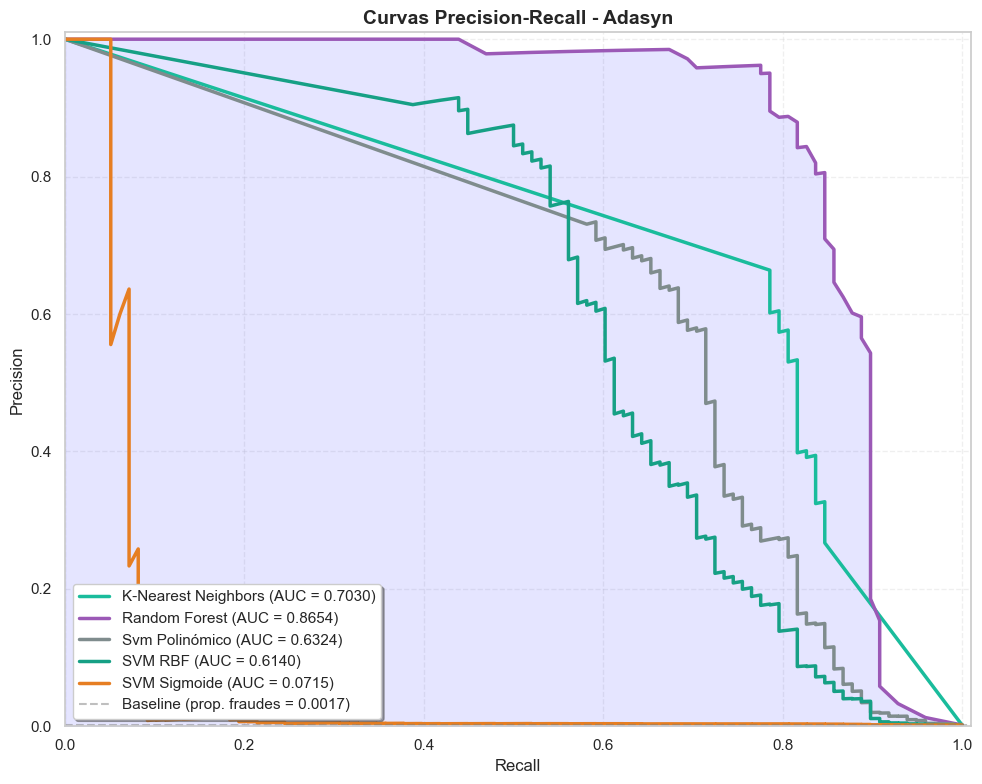


Generando curvas Precision-Recall para SMOTE_TOMEK
Gráfico guardado: 04_curvas_precision_recall_smote_tomek.png


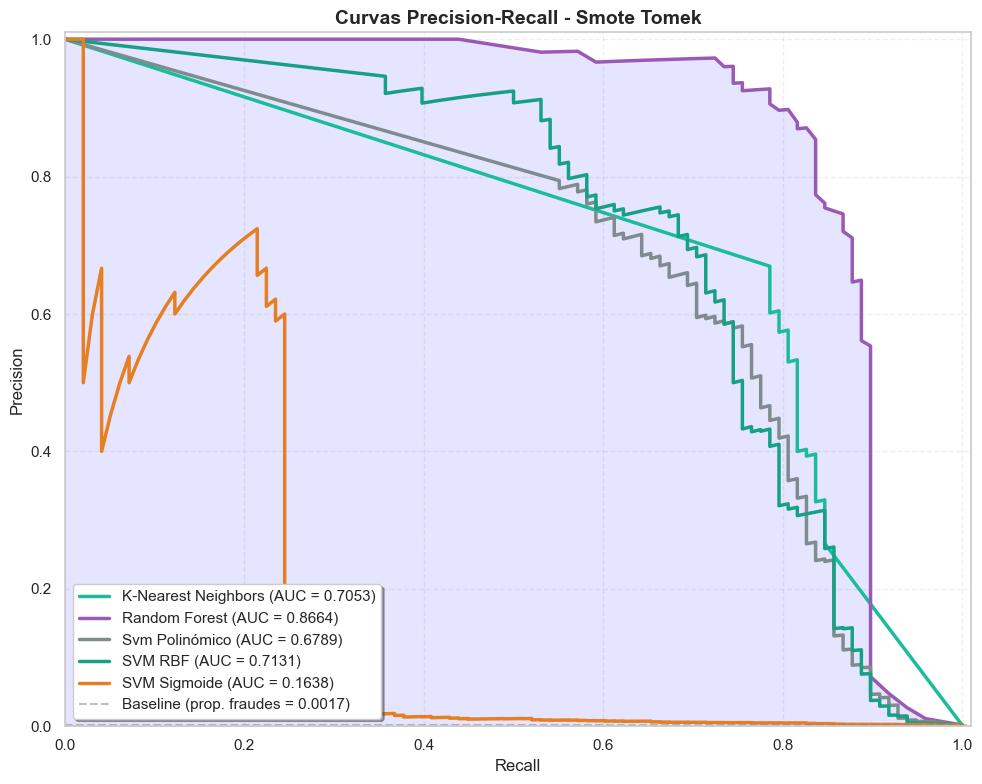

In [130]:
# Generar curvas Precision-Recall para cada método
for method, models_pred in predictions_data.items():
    if not models_pred:
        continue
    
    plt.figure(figsize=(10, 8))
    
    print(f"\nGenerando curvas Precision-Recall para {method.upper()}")
    
    # Variable para calcular baseline una sola vez
    baseline = None
    
    # Para cada modelo en este método
    for model_name, pred_data in models_pred.items():
        if pred_data.get('y_prob') is not None:
            # Obtener datos
            y_true = pred_data['y_test']
            y_prob = pred_data['y_prob']
            
            # Calcular baseline (proporción de fraudes)
            if baseline is None:
                baseline = np.mean(y_true)
            
            # Calcular curva Precision-Recall
            precision, recall, _ = precision_recall_curve(y_true, y_prob)
            pr_auc = auc(recall, precision)
            
            # Obtener color del modelo
            color = model_colors.get(model_name, '#7f8c8d')
            
            # Dibujar curva
            plt.plot(recall, precision, lw=2.5, color=color,
                    label=f'{model_name} (AUC = {pr_auc:.4f})')
    
    # Línea base (proporción de fraudes)
    if baseline is not None:
        plt.axhline(y=baseline, color='gray', linestyle='--', alpha=0.5,
                   label=f'Baseline (prop. fraudes = {baseline:.4f})')
    
    # Configuración del gráfico
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(f'Curvas Precision-Recall - {method.replace("_", " ").title()}', 
              fontsize=14, fontweight='bold')
    plt.legend(loc="lower left", frameon=True, fancybox=True, shadow=True)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.xlim([0, 1.01])
    plt.ylim([0, 1.01])
    
    # Añadir área sombreada bajo la mejor curva
    best_auc = 0
    best_precision = None
    best_recall = None
    
    for model_name, pred_data in models_pred.items():
        if pred_data.get('y_prob') is not None:
            precision, recall, _ = precision_recall_curve(pred_data['y_test'], pred_data['y_prob'])
            current_auc = auc(recall, precision)
            if current_auc > best_auc:
                best_auc = current_auc
                best_precision = precision
                best_recall = recall
    
    # Sombrear área bajo la mejor curva
    if best_recall is not None:
        plt.fill_between(best_recall, 0, best_precision, alpha=0.1, color='blue')
    
    plt.tight_layout()
    show_and_save(f'04_curvas_precision_recall_{method}')

In [138]:
# Crear tabla con Top 3 modelos por cada métrica
metrics_for_analysis = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']

print("TOP 3 MODELOS POR MÉTRICA")
print("="*60)

# Para cada métrica
for metric in metrics_for_analysis:
    if metric in unified_df.columns:
        print(f"\n{metric}:")
        print("-" * 60)
        
        # Obtener top 3
        top3 = unified_df.nlargest(3, metric)
        
        # Mostrar cada uno
        for i, (idx, row) in enumerate(top3.iterrows(), 1):
            value_str = f"{row[metric]:.6f}"
            
            # Calcular diferencia con el primero
            if i == 1:
                best_value = row[metric]
                diff_str = ""
            else:
                diff = best_value - row[metric]
                diff_str = f" (-{diff:.6f})"
            
            print(f"  {i}. {row['Método']} - {row['Modelo']}: {value_str}{diff_str}")

# Crear DataFrame resumen para guardar
top3_summary = []
for metric in metrics_for_analysis:
    if metric in unified_df.columns:
        top3 = unified_df.nlargest(3, metric)
        for rank, (idx, row) in enumerate(top3.iterrows(), 1):
            top3_summary.append({
                'Métrica': metric,
                'Ranking': rank,
                'Método': row['Método'],
                'Modelo': row['Modelo'],
                'Valor': row[metric]
            })

top3_df = pd.DataFrame(top3_summary)

# Guardar
top3_df.to_csv(os.path.join(results_dir, 'top3_modelos_por_metrica.csv'), index=False)
print(f"\nTabla Top 3 guardada en: top3_modelos_por_metrica.csv")

# Mostrar el DataFrame resumen
display(top3_df)

TOP 3 MODELOS POR MÉTRICA

Accuracy:
------------------------------------------------------------
  1. Original - Random Forest: 0.999561
  2. Original - K-Nearest Neighbors: 0.999508 (-0.000053)
  3. Smote - Random Forest: 0.999491 (-0.000070)

Precision:
------------------------------------------------------------
  1. Original - K-Nearest Neighbors: 0.960526
  2. Original - Random Forest: 0.929412 (-0.031115)
  3. Adasyn - Random Forest: 0.895349 (-0.065177)

Recall:
------------------------------------------------------------
  1. Smote - SVM Polinómico: 0.887755
  2. Smote - SVM RBF: 0.887755 (-0.000000)
  3. Adasyn - SVM Polinómico: 0.887755 (-0.000000)

F1-Score:
------------------------------------------------------------
  1. Original - Random Forest: 0.863388
  2. Smote - Random Forest: 0.848168 (-0.015220)
  3. Smote Tomek - Random Forest: 0.848168 (-0.015220)

ROC-AUC:
------------------------------------------------------------
  1. Smote - SVM Polinómico: 0.973981
  2. Sm

,Métrica,Ranking,Método,Modelo,Valor
0,Accuracy,1,Original,Random Forest,0.999561
1,Accuracy,2,Original,K-Nearest Neighbors,0.999508
2,Accuracy,3,Smote,Random Forest,0.999491
3,Precision,1,Original,K-Nearest Neighbors,0.960526
4,Precision,2,Original,Random Forest,0.929412
5,Precision,3,Adasyn,Random Forest,0.895349
6,Recall,1,Smote,SVM Polinómico,0.887755
7,Recall,2,Smote,SVM RBF,0.887755
8,Recall,3,Adasyn,SVM Polinómico,0.887755
9,F1-Score,1,Original,Random Forest,0.863388


In [144]:
# Crear función para aplicar estilos sin modificar valores
def style_top_two_values(s, ascending=False):
    """
    Aplica negrita al mejor valor y subrayado al segundo mejor
    sin modificar los valores originales
    """
    # Convertir a valores numéricos para comparar
    values = pd.to_numeric(s, errors='coerce')
    
    # Crear serie de estilos vacía
    styles = [''] * len(values)
    
    # Encontrar los dos mejores valores
    valid_values = values.dropna()
    if len(valid_values) >= 2:
        if ascending:
            # Para tiempos: menor es mejor
            sorted_values = valid_values.nsmallest(2)
        else:
            # Para métricas: mayor es mejor
            sorted_values = valid_values.nlargest(2)
            
        best_value = sorted_values.iloc[0]
        second_best = sorted_values.iloc[1]
        
        # Aplicar estilos
        for i in range(len(values)):
            if values.iloc[i] == best_value:
                styles[i] = 'font-weight: bold'  # Negrita para el mejor
            elif values.iloc[i] == second_best:
                styles[i] = 'text-decoration: underline'  # Subrayado para el segundo
    
    return styles

display_df = unified_df.copy()
metrics_to_highlight = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'PR-AUC']
time_columns = ['Train Time (s)', 'Prediction Time (s)']

# Crear objeto de estilo
styled_df = display_df.style

# Aplicar estilos a métricas
for metric in metrics_to_highlight:
    if metric in display_df.columns:
        styled_df = styled_df.apply(lambda s: style_top_two_values(s, ascending=False), subset=[metric])

# Aplicar estilos a tiempos
for time_col in time_columns:
    if time_col in display_df.columns:
        styled_df = styled_df.apply(lambda s: style_top_two_values(s, ascending=True), subset=[time_col])

styled_df = styled_df.set_caption("Tabla de Resultados: Negrita = mejor valor, Subrayado = segundo mejor")

display(styled_df)

# Guardar versión HTML con estilos
html_output = styled_df.to_html()
html_path = os.path.join(results_dir, 'tabla_resultados_destacados.html')
with open(html_path, 'w', encoding='utf-8') as f:
    f.write(html_output)
print(f"\nTabla HTML con estilos guardada en: tabla_resultados_destacados.html")

,Método,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,False Positive Rate,Train Time (s),Prediction Time (s)
0,Original,Random Forest,0.999561,0.929412,0.806122,0.863388,0.952769,0.872467,0.000106,58.130314,0.249988
1,Original,K-Nearest Neighbors,0.999508,0.960526,0.744898,0.839080,0.918246,0.860121,0.000053,0.041461,53.247644
2,Original,SVM Polinómico,0.999122,0.760870,0.714286,0.736842,0.947699,0.797347,0.000387,255.456358,0.581871
3,Original,SVM Sigmoide,0.998560,0.617647,0.428571,0.506024,0.731252,0.347016,0.000457,57.153295,1.219020
4,Original,SVM RBF,0.999280,0.782178,0.806122,0.793970,0.945351,0.787897,0.000387,111.329176,3.214249
5,Smote,Random Forest,0.999491,0.870968,0.826531,0.848168,0.973011,0.866403,0.000211,139.449402,0.312952
6,Smote,K-Nearest Neighbors,0.997507,0.393204,0.826531,0.532895,0.922792,0.705311,0.002198,0.065372,66.092740
7,Smote,SVM Polinómico,0.983866,0.087437,0.887755,0.159195,0.973981,0.678941,0.015968,14614.899276,157.553278
8,Smote,SVM Sigmoide,0.736684,0.004983,0.765306,0.009902,0.819929,0.163776,0.263365,19347.597631,389.548635
9,Smote,SVM RBF,0.984621,0.091387,0.887755,0.165714,0.966054,0.713080,0.015212,7507.445279,228.150879



Tabla HTML con estilos guardada en: tabla_resultados_destacados.html
